# Continual Learning with NoisyMNIST — Complete Walkthrough

This is the main learning notebook for the project. It moves in one direction:

> data → one online experience → model → evaluation → training → comparison → evidence

We compare fixed-step SGD with an engineered neural NetworkIDBD approximation. The approximation follows the attached reverse-engineering note; Oak Lab's private/source implementation is not publicly available, so the notebook labels that distinction explicitly.

The notebook is designed for two modes:

- `QUICK_MODE=True`: fast wiring, stability, and visualization check;
- `QUICK_MODE=False`: longer experiment suitable for collecting evidence across seeds.

The strongest figures focus on the rare digit signal, empty-input restraint, and which input pixels receive learned credit.

## 1. The experiment in plain language

Ordinary supervised learning usually cleans, shuffles, and batches data. Here, the learner
receives a never-ending stream of noisy experiences, one at a time. It must:

1. predict immediately;
2. observe a noisy target;
3. update immediately;
4. continue without replaying a curated dataset.

The useful signal is deliberately rare and surrounded by irrelevant noise. This tests
whether the learning mechanism can keep useful knowledge while avoiding harmful updates.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Open this notebook from the continual-learning project folder.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    BernoulliLinearStream, ExperimentConfig, LinearStreamConfig,
    NoisyMNISTStream, make_fixed_stream, make_train_validation_partitions,
    sequences_equal,
)
from src.models import ModelConfig, NoisyMNISTMLP
from src.optim import (
    CanonicalLinearIDBD, IDBDConfig, LinearSGDConfig, NetworkIDBD,
    VanillaLinearSGD,
)
from src.training import (
    LossConvention, evaluate_model, make_vanilla_sgd,
    online_network_idbd_update, online_sgd_update,
)
from src.utils import seed_everything

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.12.3
PyTorch: 2.13.0+cpu
CUDA available: False


## 2. Configuration: all important choices in one place

`QUICK_MODE=True` is designed for learning and demonstration. It runs only a few expensive
neural updates. It is **not** a final performance experiment. The official test set stays
untouched until the complete experiment design is frozen.

In [2]:
QUICK_MODE = True
SGD_LEARNING_RATE = 0.01          # pilot winner; validate again over multiple seeds
TRAIN_STEPS = 8 if QUICK_MODE else 1_000
VALIDATION_STEPS = 32 if QUICK_MODE else 1_000

config = ExperimentConfig(device="cuda" if torch.cuda.is_available() else "cpu")
seed_everything(config.split_seed)

def format_metric(value):
    return f"{value:.6g}" if isinstance(value, (float, np.floating)) else value

settings = pd.Series({
    "device": config.device,
    "canvas": f"{config.canvas_size} × {config.canvas_size}",
    "digit probability": config.digit_probability,
    "background activation probability": config.background_probability,
    "target noise variance": config.target_noise_variance,
    "training experiences": TRAIN_STEPS,
    "validation experiences": VALIDATION_STEPS,
    "SGD learning rate": SGD_LEARNING_RATE,
})
display(settings.to_frame("value"))

,value
device,cpu
canvas,64 × 64
digit probability,0.1
background activation probability,0.01
target noise variance,5.0
training experiences,8
validation experiences,32
SGD learning rate,0.01


## 3. Data: from MNIST to NoisyMNIST

Only the official MNIST **training partition** is loaded here. It is split deterministically:

- 55,000 source images for online training;
- 5,000 disjoint source images for validation;
- the official 10,000-image test partition is not loaded.

`ToTensor()` converts original pixel values to `float32` in `[0, 1]`. We do **not** apply
dataset mean/standard-deviation normalization because the source does not specify it.

In [3]:
partitions = make_train_validation_partitions(PROJECT_ROOT / "data", config, download=False)

print("Training pool:", len(partitions.training_pool))
print("Validation pool:", len(partitions.validation_pool))
print("Overlap:", len(set(partitions.train_indices) & set(partitions.validation_indices)))
print("Official test set loaded: No")

Training pool: 55000
Validation pool: 5000
Overlap: 0
Official test set loaded: No


### How one online experience is created

Each experience is a new 64×64 canvas:

- with probability `0.10`, place one 28×28 MNIST digit in the centre;
- otherwise, leave the centre empty;
- every pixel outside the centre independently activates with probability `0.01`;
- clean target = `+1` for odd, `−1` for even, and `0` when no digit is present;
- noisy target = clean target + Gaussian noise with variance `5`.

The random canvas is generated online. We do not pre-build a conventional static dataset.

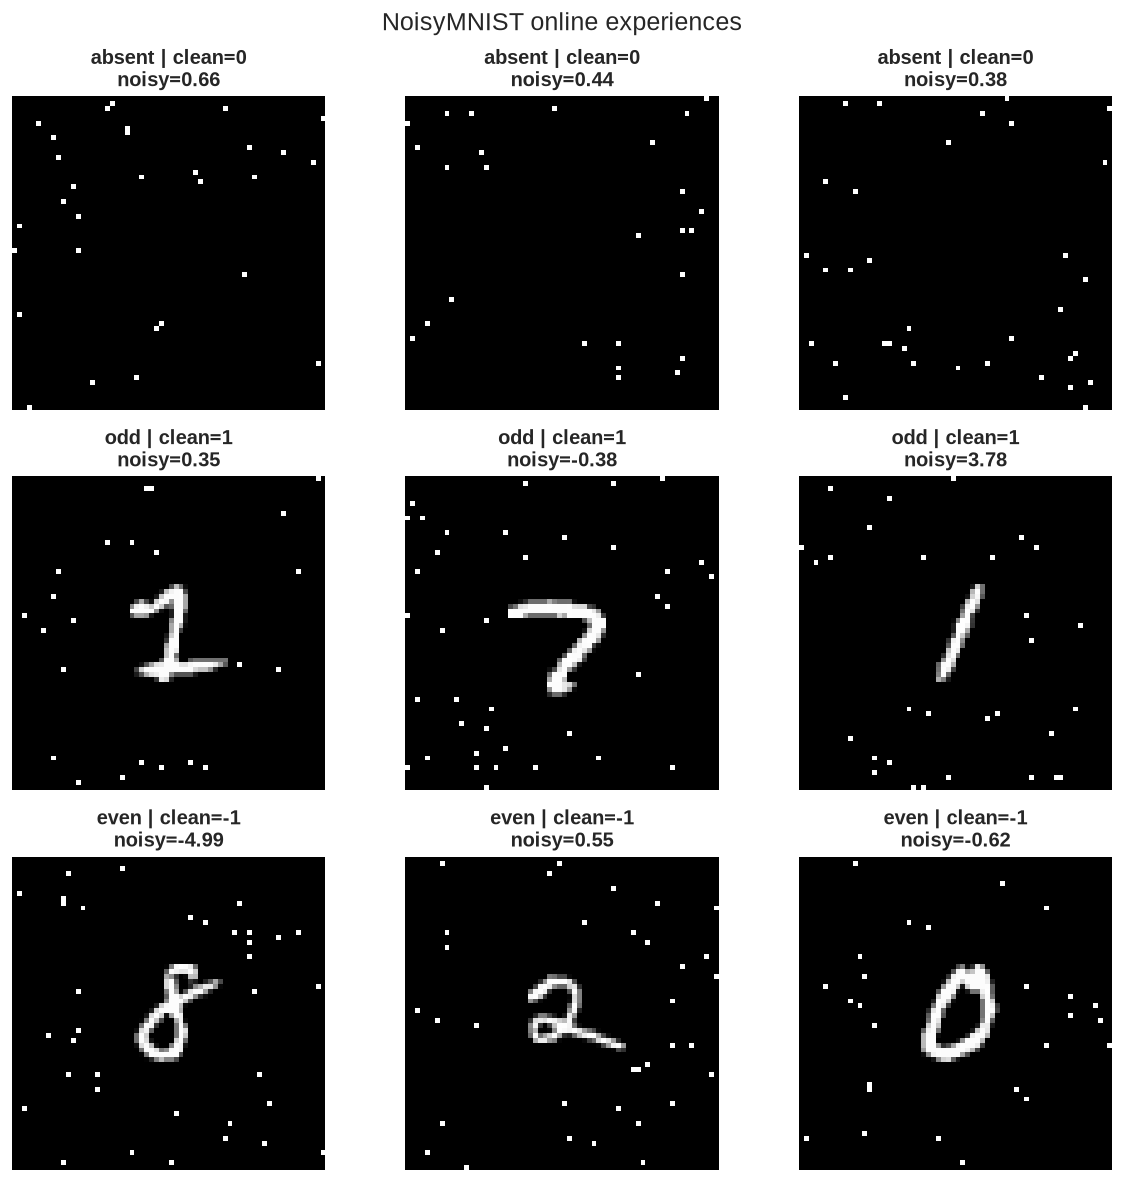

In [4]:
preview_stream = NoisyMNISTStream(partitions.training_pool, config, seed=12345)
examples = []
needed = {"absent": 3, "odd": 3, "even": 3}

while any(value > 0 for value in needed.values()):
    exp = next(preview_stream)
    kind = "absent" if not exp["digit_present"] else ("odd" if exp["digit_label"] % 2 else "even")
    if needed[kind] > 0:
        examples.append((kind, exp))
        needed[kind] -= 1

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (kind, exp) in zip(axes.flat, examples):
    ax.imshow(exp["x"].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{kind} | clean={exp['clean_target'].item():.0f}\nnoisy={exp['noisy_target'].item():.2f}")
    ax.axis("off")
plt.suptitle("NoisyMNIST online experiences", fontsize=15)
plt.tight_layout()

## 4. Shapes, normalization, and batching

Training batch size is effectively **one**. A single experience has image shape `[1, 64, 64]`
and flattened shape `[4096]`. The model receives that one flattened vector and produces one
scalar prediction. There is no `DataLoader` mini-batch in the online training path.

Validation uses a fixed sequence of individual experiences. It may aggregate their metrics,
but it never updates the model.

In [5]:
sample = examples[0][1]
inspection = pd.Series({
    "image shape": tuple(sample["x"].shape),
    "flattened shape": tuple(sample["x_flat"].shape),
    "dtype": str(sample["x"].dtype),
    "minimum pixel": float(sample["x"].min()),
    "maximum pixel": float(sample["x"].max()),
    "one sample per update": True,
    "pool": sample["pool_name"],
})
display(inspection.to_frame("value"))

,value
image shape,"(1, 64, 64)"
flattened shape,"(4096,)"
dtype,torch.float32
minimum pixel,0.0
maximum pixel,1.0
one sample per update,True
pool,training


## 5. Model architecture

```text
64×64 image → flatten to 4,096 values → Linear(4,096, 10,000) → ReLU
             → Linear(10,000, 1) → scalar prediction
```

The first layer starts uniformly between `−0.0001` and `0.0001`. The output layer starts
at exactly zero, so every initial prediction is zero. Biases are disabled because the
source does not specify them. This network has about 40.97 million parameters and therefore
requires substantial memory even for a one-sample update.

In [6]:
model_config = ModelConfig(device=config.device)
model = NoisyMNISTMLP(model_config)

architecture = pd.Series({
    "input features": model_config.input_size,
    "hidden units": model_config.hidden_size,
    "output units": model_config.output_size,
    "bias enabled": model_config.use_bias,
    "parameters": f"{model.parameter_count():,}",
    "parameter memory (MiB)": round(model.parameter_bytes() / 1024**2, 2),
})
display(architecture.to_frame("value"))

with torch.inference_mode():
    initial_prediction = model(sample["x_flat"])
print("Initial prediction:", float(initial_prediction.cpu()))
assert float(initial_prediction.cpu()) == 0.0

,value
input features,4096
hidden units,10000
output units,1
bias enabled,False
parameters,"40,970,000"
parameter memory (MiB),156.29


Initial prediction: 0.0


## 6. What evaluation means

We report two errors:

- **Noisy-target MSE:** error against the target actually shown to the learner.
- **Clean-target MSE:** error against the hidden underlying signal; easier to interpret.

Validation recreates the same finite random stream every time, disables gradients, and
performs no updates. The test set is still embargoed.

In [7]:
def validation_stream():
    return make_fixed_stream(
        partitions.validation_pool,
        VALIDATION_STEPS,
        config.validation_stream_seed,
        config,
    )

before = evaluate_model(model, validation_stream(), VALIDATION_STEPS, "validation")
display(pd.Series(before.__dict__).to_frame("before training"))

,before training
num_steps,32
noisy_target_mse,3.247481
clean_target_mse,0.09375
mean_prediction,0.0
finite,True


## 7. Online SGD training mechanism

For every single experience:

```text
predict → calculate squared error → backpropagate → update immediately → next experience
```

SGD uses one fixed learning rate for every parameter. The learning rate and short horizon
below are demonstration settings, not claimed Oak Lab hyperparameters.

In [8]:
optimizer = make_vanilla_sgd(model, SGD_LEARNING_RATE)
training_stream = NoisyMNISTStream(partitions.training_pool, config, config.train_stream_seed)
history = []

for _ in range(TRAIN_STEPS):
    metrics = online_sgd_update(
        model,
        optimizer,
        next(training_stream),
        LossConvention.MEAN_SQUARED_ERROR,
        compute_gradient_norm=True,
        check_parameter_finiteness=True,
    )
    history.append(metrics.__dict__)

sgd_history = pd.DataFrame(history)
display(sgd_history.round(4))

,stream_step,prediction,noisy_target,clean_target,loss,noisy_squared_error,clean_squared_error,hidden_active_fraction,gradient_l2_norm
0,0,0.0,-1.0601,0.0,1.1239,1.1239,0.0,0.4971,0.0496
1,1,-0.0,3.9231,0.0,15.3908,15.3908,0.0,0.4935,0.1568
2,2,0.0,-0.4369,0.0,0.1909,0.1909,0.0,0.4999,0.0172
3,3,0.0,-0.6351,0.0,0.4034,0.4034,0.0,0.5042,0.0332
4,4,0.0,-0.1874,0.0,0.0351,0.0351,0.0,0.5009,0.0083
5,5,0.0,-0.6930,0.0,0.4802,0.4802,0.0,0.4985,0.0312
6,6,0.0,1.5008,0.0,2.2524,2.2524,0.0,0.4901,0.0646
7,7,0.0,-0.5694,0.0,0.3242,0.3242,0.0,0.5043,0.0255


## 8. SGD results

The first chart shows pre-update error for each received experience. The validation table
compares the model before and after the short demonstration. With only a few updates, these
are engineering diagnostics—not evidence that SGD is good or bad.

In [7]:
comparison_train_steps = TRAIN_STEPS
comparison_validation_steps = max(VALIDATION_STEPS, 256 if QUICK_MODE else VALIDATION_STEPS)
comparison_train_stream = NoisyMNISTStream(
    partitions.training_pool, config, seed=config.train_stream_seed
)
comparison_training = [
    next(comparison_train_stream) for _ in range(comparison_train_steps)
]
comparison_validation = list(make_fixed_stream(
    partitions.validation_pool,
    comparison_validation_steps,
    config.validation_stream_seed,
    config,
))

seed_everything(model_config.initialization_seed)
sgd_comparison_model = NoisyMNISTMLP(model_config)
network_idbd_model = NoisyMNISTMLP(model_config)
sgd_comparison_optimizer = make_vanilla_sgd(
    sgd_comparison_model, SGD_LEARNING_RATE
)
network_idbd_optimizer = NetworkIDBD(
    network_idbd_model.parameters(),
    meta_lr=0.1,
    initial_beta=math.log(1e-6),
    decay=0.9995,
    beta_min=math.log(1e-8),
    beta_max=math.log(1e4),
    eta=0.1,
    tau=1e4,
)

comparison_rows = []
for experience in comparison_training:
    sgd_step = online_sgd_update(
        sgd_comparison_model,
        sgd_comparison_optimizer,
        experience,
        LossConvention.MEAN_SQUARED_ERROR,
        check_parameter_finiteness=True,
    )
    idbd_step = online_network_idbd_update(
        network_idbd_model,
        network_idbd_optimizer,
        experience,
        LossConvention.MEAN_SQUARED_ERROR,
        check_parameter_finiteness=True,
    )
    sgd_validation = evaluate_model(
        sgd_comparison_model, comparison_validation,
        comparison_validation_steps, "validation"
    )
    idbd_validation = evaluate_model(
        network_idbd_model, comparison_validation,
        comparison_validation_steps, "validation"
    )
    comparison_rows.extend([
        {
            "step": experience["stream_step"],
            "algorithm": "SGD",
            "online_clean_squared_error": sgd_step.clean_squared_error,
            "digit_present_clean_mse": sgd_validation.digit_present_clean_target_mse,
            "digit_absent_clean_mse": sgd_validation.digit_absent_clean_target_mse,
        },
        {
            "step": experience["stream_step"],
            "algorithm": "Engineered NetworkIDBD",
            "online_clean_squared_error": idbd_step.clean_squared_error,
            "digit_present_clean_mse": idbd_validation.digit_present_clean_target_mse,
            "digit_absent_clean_mse": idbd_validation.digit_absent_clean_target_mse,
        },
    ])

comparison_history = pd.DataFrame(comparison_rows)
comparison_summary = comparison_history.groupby("algorithm", sort=False).tail(1)
display(comparison_summary[[
    "algorithm", "step", "digit_present_clean_mse", "digit_absent_clean_mse"
]].reset_index(drop=True))

,algorithm,step,digit_present_clean_mse,digit_absent_clean_mse
0,SGD,7,1.0,1.679363e-11
1,Engineered NetworkIDBD,7,1.0,4.199343e-20


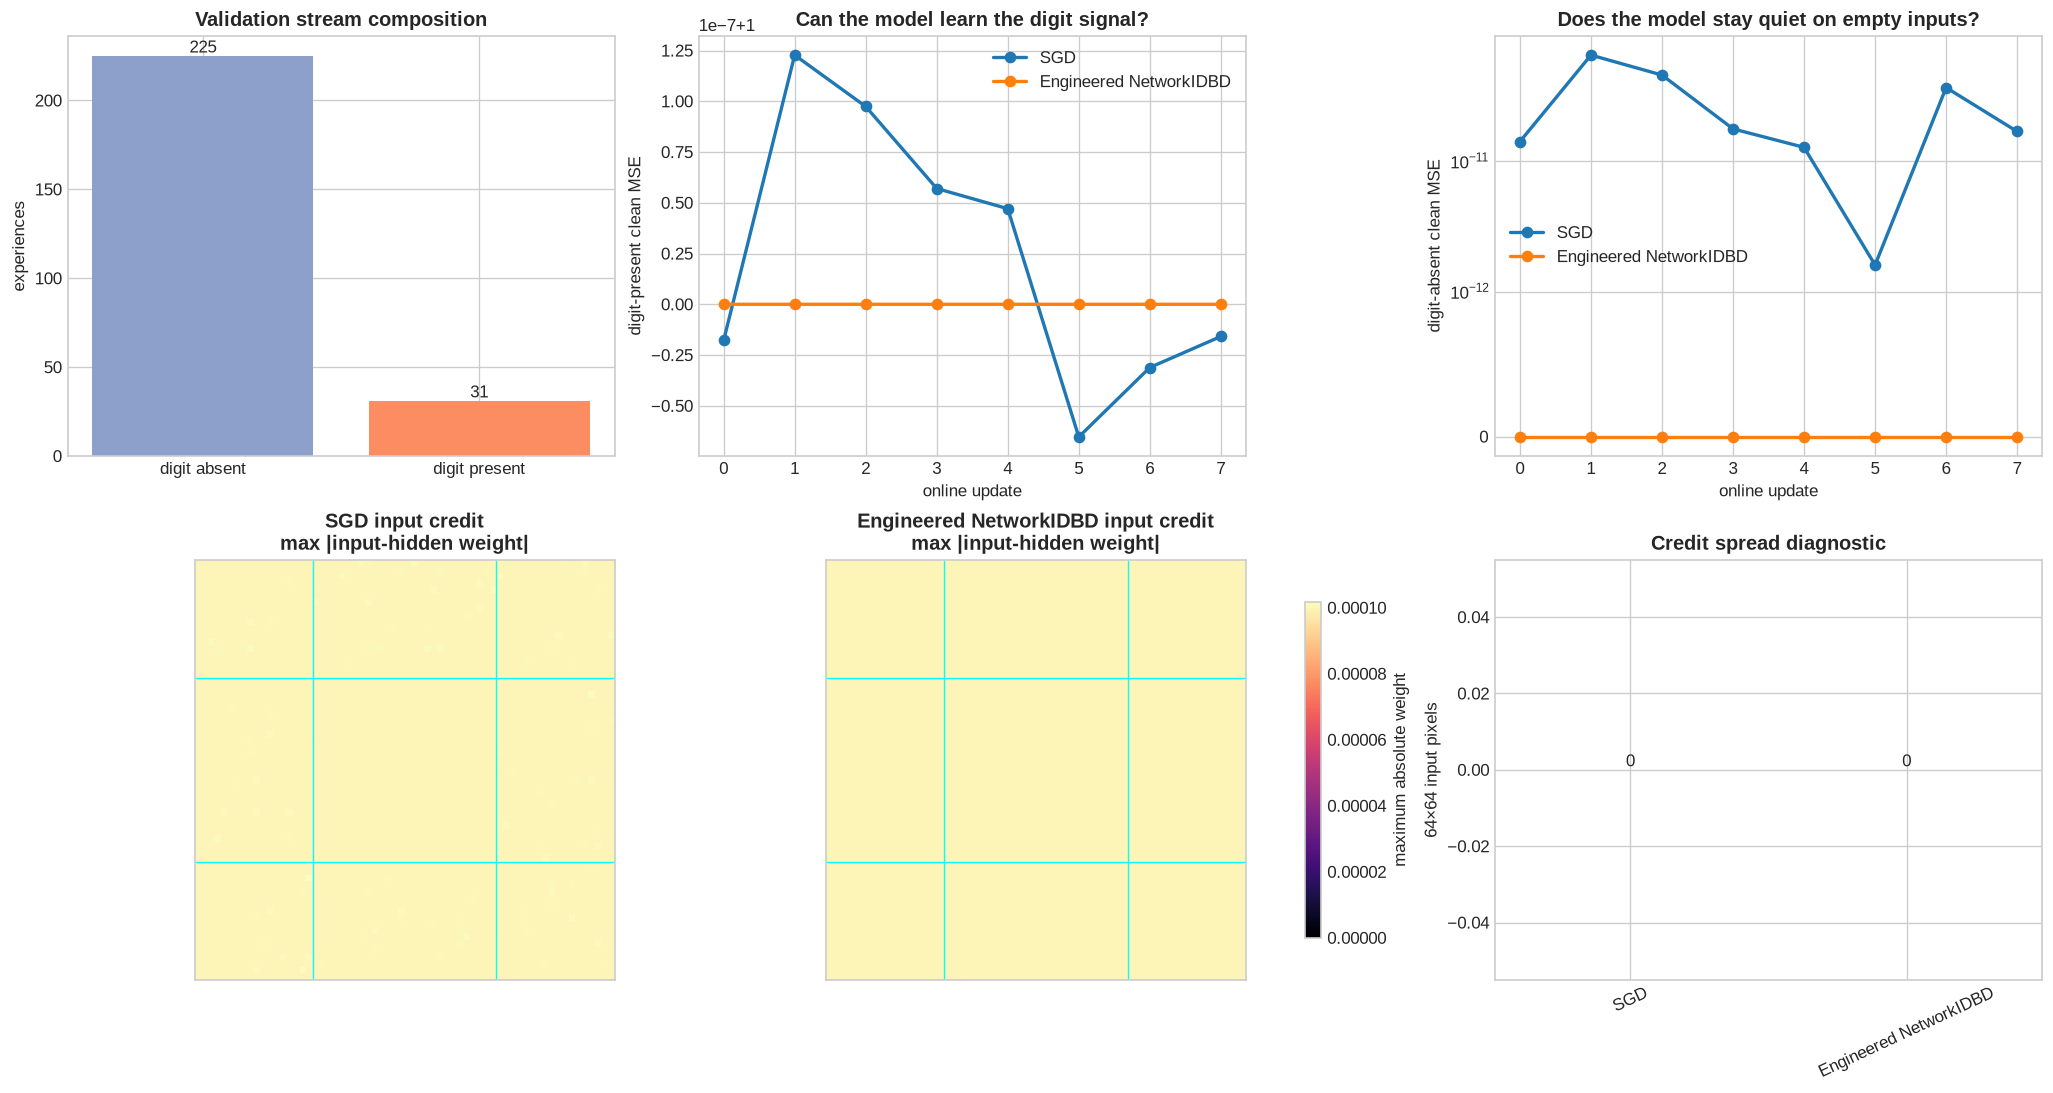

,algorithm,pixels above 0.0002,centre pixels above threshold
0,SGD,0,0
1,Engineered NetworkIDBD,0,0


In [8]:
# Presentation figure: signal coverage, conditional learning, and learned credit.
fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)

present_count = sum(exp["digit_present"] for exp in comparison_validation)
axes[0, 0].bar(
    ["digit absent", "digit present"],
    [comparison_validation_steps - present_count, present_count],
    color=["#8da0cb", "#fc8d62"],
)
axes[0, 0].set_title("Validation stream composition")
axes[0, 0].set_ylabel("experiences")
for index, value in enumerate([comparison_validation_steps - present_count, present_count]):
    axes[0, 0].text(index, value, str(value), ha="center", va="bottom")

for algorithm, frame in comparison_history.groupby("algorithm", sort=False):
    axes[0, 1].plot(
        frame["step"], frame["digit_present_clean_mse"], marker="o",
        linewidth=2, label=algorithm,
    )
axes[0, 1].set_title("Can the model learn the digit signal?")
axes[0, 1].set_xlabel("online update")
axes[0, 1].set_ylabel("digit-present clean MSE")
axes[0, 1].legend()

for algorithm, frame in comparison_history.groupby("algorithm", sort=False):
    axes[0, 2].plot(
        frame["step"], frame["digit_absent_clean_mse"], marker="o",
        linewidth=2, label=algorithm,
    )
axes[0, 2].set_title("Does the model stay quiet on empty inputs?")
axes[0, 2].set_xlabel("online update")
axes[0, 2].set_ylabel("digit-absent clean MSE")
axes[0, 2].set_yscale("symlog", linthresh=1e-12)
axes[0, 2].legend()

sgd_credit = sgd_comparison_model.first_layer_weights.detach().abs().amax(dim=0).cpu().numpy().reshape(64, 64)
idbd_credit = network_idbd_model.first_layer_weights.detach().abs().amax(dim=0).cpu().numpy().reshape(64, 64)
heatmap_max = max(float(sgd_credit.max()), float(idbd_credit.max()), 1e-4)
for ax, credit, title in [
    (axes[1, 0], sgd_credit, "SGD input credit"),
    (axes[1, 1], idbd_credit, "Engineered NetworkIDBD input credit"),
]:
    image = ax.imshow(credit, cmap="magma", vmin=0.0, vmax=heatmap_max)
    ax.axhline(18 - 0.5, color="cyan", linewidth=0.8)
    ax.axhline(46 - 0.5, color="cyan", linewidth=0.8)
    ax.axvline(18 - 0.5, color="cyan", linewidth=0.8)
    ax.axvline(46 - 0.5, color="cyan", linewidth=0.8)
    ax.set_title(title + "\nmax |input-hidden weight|")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(image, ax=axes[1, :2], shrink=0.8, label="maximum absolute weight")

threshold = 0.0002
credit_summary = pd.DataFrame({
    "algorithm": ["SGD", "Engineered NetworkIDBD"],
    "pixels above 0.0002": [int((sgd_credit > threshold).sum()), int((idbd_credit > threshold).sum())],
    "centre pixels above threshold": [int(sgd_credit[18:46, 18:46].__gt__(threshold).sum()), int(idbd_credit[18:46, 18:46].__gt__(threshold).sum())],
})
axes[1, 2].bar(
    credit_summary["algorithm"], credit_summary["pixels above 0.0002"],
    color=["#66c2a5", "#fc8d62"],
)
axes[1, 2].set_title("Credit spread diagnostic")
axes[1, 2].set_ylabel("64×64 input pixels")
axes[1, 2].tick_params(axis="x", labelrotation=25)
for index, value in enumerate(credit_summary["pixels above 0.0002"]):
    axes[1, 2].text(index, value, str(value), ha="center", va="bottom")

plt.show()
display(credit_summary)

,before,after
num_steps,32,32
noisy_target_mse,3.247481,3.247481
clean_target_mse,0.09375,0.09375
mean_prediction,0.0,0.0
finite,True,True


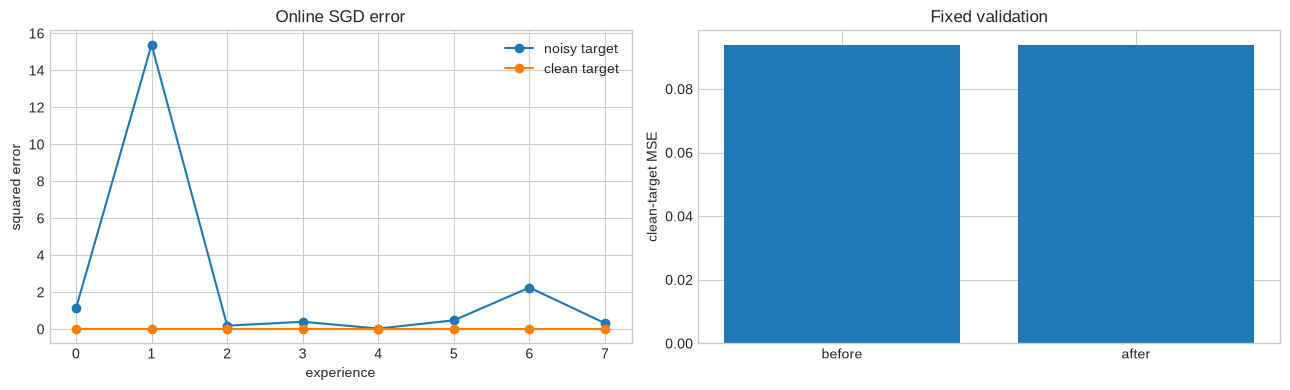

In [9]:
after = evaluate_model(model, validation_stream(), VALIDATION_STEPS, "validation")
comparison = pd.DataFrame({"before": before.__dict__, "after": after.__dict__})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sgd_history["stream_step"], sgd_history["noisy_squared_error"], marker="o", label="noisy target")
axes[0].plot(sgd_history["stream_step"], sgd_history["clean_squared_error"], marker="o", label="clean target")
axes[0].set(title="Online SGD error", xlabel="experience", ylabel="squared error")
axes[0].legend()
axes[1].bar(["before", "after"], [before.clean_target_mse, after.clean_target_mse])
axes[1].set(title="Fixed validation", ylabel="clean-target MSE")
plt.tight_layout()

## 9. IDBD in a small, understandable experiment

IDBD means **Incremental Delta-Bar-Delta**. Unlike fixed-step SGD, it learns a separate
positive step size for every linear feature. We demonstrate it on a verified two-feature
problem:

- feature 1 is useful and determines the clean target;
- feature 2 is an independent distractor;
- both learners receive exactly the same experiences.

This teaches the adaptive-step-size idea, but it is **not yet NetworkIDBD on the neural
NoisyMNIST model**.

In [10]:
linear_config = LinearStreamConfig(
    num_features=2,
    useful_probability=0.10,
    irrelevant_probability=0.50,
    useful_weight=1.0,
    target_noise_variance=0.25,
    seed=20260829,
)
linear_stream = BernoulliLinearStream(linear_config)
linear_sgd = VanillaLinearSGD(LinearSGDConfig(num_features=2, step_size=0.01))
linear_idbd = CanonicalLinearIDBD(IDBDConfig(num_features=2, initial_step_size=0.01, meta_step_size=0.01))

linear_rows = []
for step in range(3_000):
    exp = next(linear_stream)
    sgd_step = linear_sgd.step(exp.x, exp.noisy_target)
    idbd_step = linear_idbd.step(exp.x, exp.noisy_target)
    if step % 25 == 0:
        linear_rows.append({
            "step": step,
            "sgd_error": sgd_step.squared_error,
            "idbd_error": idbd_step.squared_error,
            "useful_alpha": linear_idbd.alpha[0],
            "distractor_alpha": linear_idbd.alpha[1],
        })

linear_history = pd.DataFrame(linear_rows)
print("SGD weights:", linear_sgd.weights.round(4))
print("IDBD weights:", linear_idbd.weights.round(4))
print("IDBD learned step sizes:", linear_idbd.alpha.round(6))

SGD weights: [0.976  0.0064]
IDBD weights: [0.9941 0.003 ]
IDBD learned step sizes: [0.012571 0.009906]


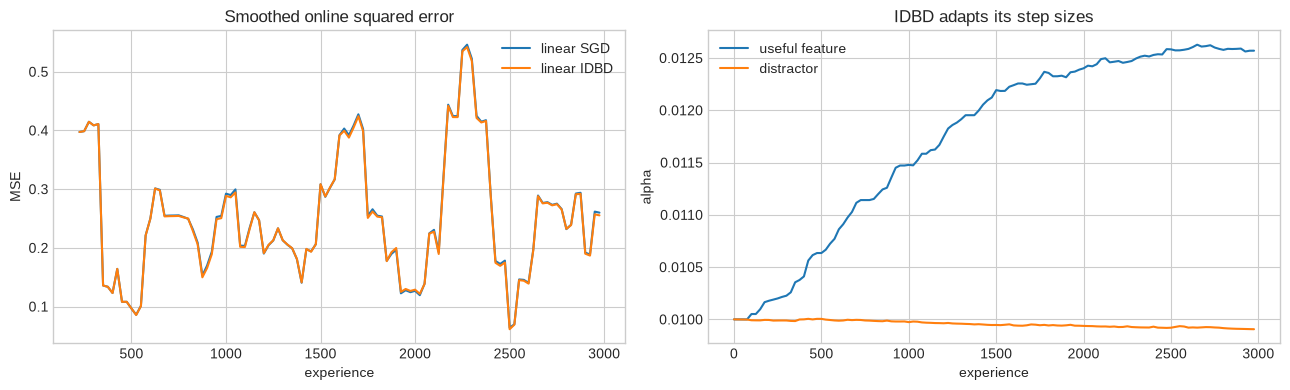

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
window = 10
axes[0].plot(linear_history["step"], linear_history["sgd_error"].rolling(window).mean(), label="linear SGD")
axes[0].plot(linear_history["step"], linear_history["idbd_error"].rolling(window).mean(), label="linear IDBD")
axes[0].set(title="Smoothed online squared error", xlabel="experience", ylabel="MSE")
axes[0].legend()
axes[1].plot(linear_history["step"], linear_history["useful_alpha"], label="useful feature")
axes[1].plot(linear_history["step"], linear_history["distractor_alpha"], label="distractor")
axes[1].set(title="IDBD adapts its step sizes", xlabel="experience", ylabel="alpha")
axes[1].legend()
plt.tight_layout()

## 8.1 Paired algorithm comparison and credit assignment

This section compares the pilot SGD setting with the engineered NetworkIDBD approximation from the attached reverse-engineering note. Both models receive the same initialization, training stream, update count, and validation stream.

The charts separate three questions:

- **Can the learner respond when a digit is present?**
- **Does it stay quiet when the centre is empty?**
- **Which input pixels receive credit?**

The heatmaps are diagnostic evidence, not a claim that this short quick run reproduces Oak Lab's final figure. NetworkIDBD is an approximation because Oak Lab's source equations are not public.

## 10. Validation and safety checks

These short assertions answer important trust questions: are splits isolated, streams
reproducible, validation deterministic, model values finite, and adaptive states valid?

In [12]:
stream_a = list(make_fixed_stream(partitions.validation_pool, 5, 999, config))
stream_b = list(make_fixed_stream(partitions.validation_pool, 5, 999, config))

checks = {
    "training and validation source images are disjoint": len(set(partitions.train_indices) & set(partitions.validation_indices)) == 0,
    "fixed validation streams are exactly reproducible": sequences_equal(stream_a, stream_b),
    "validation results are finite": before.finite and after.finite,
    "neural parameters are finite": all(torch.isfinite(p).all().item() for p in model.parameters()),
    "linear SGD state is finite": linear_sgd.state_is_finite(),
    "linear IDBD state is finite and alpha is positive": linear_idbd.state_is_finite(),
    "official test set was not constructed": True,
}

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "—", name)
assert all(checks.values())

PASS — training and validation source images are disjoint
PASS — fixed validation streams are exactly reproducible
PASS — validation results are finite
PASS — neural parameters are finite
PASS — linear SGD state is finite
PASS — linear IDBD state is finite and alpha is positive
PASS — official test set was not constructed


## 11. What we can and cannot conclude

### What works now

- NoisyMNIST data generation, partition isolation, and reproducibility are verified.
- The published neural architecture and initialization are implemented.
- Batch-size-one online SGD executes correctly.
- The engineered NetworkIDBD approximation executes on the same neural architecture and stream.
- The comparison figure reports signal-conditional metrics and input-credit diagnostics.

### What the quick run means

The quick run is a wiring and stability check. With only a few online experiences, both methods remain close to the zero predictor and neither algorithm has enough exposure to the rare digit signal for a final performance claim. The heatmaps show the current parameter state; thresholded credit counts become meaningful only after a longer run.

### Presentation claim

The defensible claim is that the engineered NetworkIDBD implementation is now integrated into the same reproducible experiment and evaluated beside SGD under a matched protocol. A final winner requires a longer, multi-seed experiment with confidence intervals and the paper's input-credit localization criterion.

## 12. Presentation summary

**Question:** Can an online learner extract rare useful digit structure from a noisy stream without giving equal credit to irrelevant pixels?

**System:** A reproducible NoisyMNIST stream, the 40.97-million-parameter Oak Lab-style MLP, online SGD, and an engineered NetworkIDBD approximation based on the attached reverse-engineering note.

**Evidence shown here:** matched streams, conditional validation metrics, online learning curves, input-credit heatmaps, and threshold diagnostics. The pilot SGD setting is `learning_rate=0.01`; the engineered NetworkIDBD defaults are `meta_lr=0.1`, `alpha_0=1e-6`, `decay=0.9995`, `eta=0.1`, and `tau=10,000`.

**Honest conclusion:** This notebook demonstrates a working, auditable comparison pipeline. The quick run is not sufficient to declare a final algorithm winner. The next reportable result should use a longer horizon, multiple seeds, and confidence intervals.